In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df= pd.read_csv("bank.csv.xls.final")
df.head()

,age,education,default,balance,loan,contact,day,month,duration,campaign,...,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,housing_yes
0,59,secondary,no,0.104371,no,unknown,5,may,1042,1,...,False,False,False,False,False,False,False,False,False,True
1,56,secondary,no,0.078273,no,unknown,5,may,1467,1,...,False,False,False,False,False,False,False,False,False,False
2,41,secondary,no,0.092185,no,unknown,5,may,1389,1,...,False,False,False,False,False,False,True,False,False,True
3,55,secondary,no,0.105882,no,unknown,5,may,579,1,...,False,False,False,False,True,False,False,False,False,True
4,54,tertiary,no,0.079851,no,unknown,5,may,673,2,...,False,False,False,False,False,False,False,False,False,False


In [12]:
binary_cols=['deposit','default', 'housing', 'loan']
df = df.replace({'yes': 1, 'no': 0})
df.head()

,age,education,default,balance,loan,contact,day,month,duration,campaign,...,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,housing_yes
0,59,secondary,0,0.104371,0,unknown,5,may,1042,1,...,False,False,False,False,False,False,False,False,False,True
1,56,secondary,0,0.078273,0,unknown,5,may,1467,1,...,False,False,False,False,False,False,False,False,False,False
2,41,secondary,0,0.092185,0,unknown,5,may,1389,1,...,False,False,False,False,False,False,True,False,False,True
3,55,secondary,0,0.105882,0,unknown,5,may,579,1,...,False,False,False,False,True,False,False,False,False,True
4,54,tertiary,0,0.079851,0,unknown,5,may,673,2,...,False,False,False,False,False,False,False,False,False,False


In [13]:
numeric_cols=df.select_dtypes(include=['number']).columns
df_numeric= df[numeric_cols]
X_reg= df_numeric.drop(['duration'], axis=1)
y_reg= df_numeric['duration']
X_train_reg, X_test_reg, y_train_reg, y_test_reg= train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

linear_model= LinearRegression()
linear_model.fit(X_train_reg,y_train_reg)
y_pred_reg= linear_model.predict(X_test_reg)

mse=mean_squared_error(y_test_reg,y_pred_reg)
mae=mean_absolute_error(y_test_reg,y_pred_reg)
r2= r2_score(y_test_reg, y_pred_reg)

print(f"(R2):{r2:.4f}")
print(f"cреднеквадратичная ошибка (MSE): {mse}")
print(f"cредняя абсолютная ошибка (MAE): {mae}")


(R2):0.0055
cреднеквадратичная ошибка (MSE): 123024.59702149048
cредняя абсолютная ошибка (MAE): 254.4001719497838


In [14]:
# для улучшения обобщающей способности модели можно использовать L1 (Lasso) или L2 (Ridge)(накладывают штраф на вектор параметров модели)
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

l2_linear_model = Ridge(alpha=2.0)
l2_linear_model.fit(X_train_reg, y_train_reg)

y_pred_ridge = l2_linear_model.predict(X_test_reg) 

mse_ridge = mean_squared_error(y_test_reg, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test_reg, y_pred_ridge)

r2 = r2_score(y_test_reg, y_pred_reg)

#R2- считает какую долю изменений (дисперсии) целевой переменной смогла уловить и объяснить моделька
print(f"Коэффициент детерминации (R2): {r2:.4f}")
print(f"Ridge среднеквадратичная ошибка (MSE): {mse_ridge}")
print(f"Ridge средняя абсолютная ошибка (MAE): {mae_ridge}")

Коэффициент детерминации (R2): 0.0055
Ridge среднеквадратичная ошибка (MSE): 123049.23406112914
Ridge средняя абсолютная ошибка (MAE): 254.42934034024952


In [15]:
%pip install matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


доля верных ответов (Accuracy): 0.7425

отчет о классификации:
               precision    recall  f1-score   support

           0       0.73      0.81      0.77      1166
           1       0.76      0.67      0.71      1067

    accuracy                           0.74      2233
   macro avg       0.74      0.74      0.74      2233
weighted avg       0.74      0.74      0.74      2233



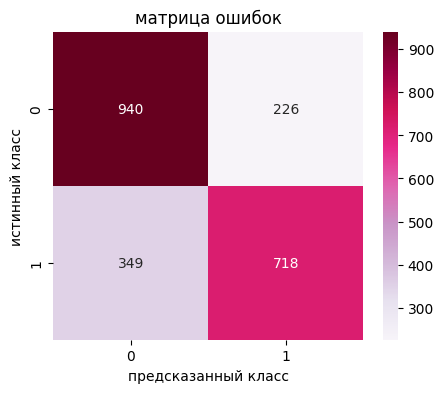

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df['deposit'] = df['deposit'].astype(int)

numeric_cols_clf = df.select_dtypes(include=['number']).columns
df_clf = df[numeric_cols_clf]

X_clf = df_clf.drop(['deposit'], axis=1)
y_clf = df_clf['deposit']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

logreg_model = LogisticRegression(max_iter=5000)
logreg_model.fit(X_train_clf, y_train_clf)

y_pred_clf = logreg_model.predict(X_test_clf)

accuracy = accuracy_score(y_test_clf, y_pred_clf)
print(f"доля верных ответов (Accuracy): {accuracy:.4f}\n")

report = classification_report(y_test_clf, y_pred_clf)
print("отчет о классификации:\n", report)

cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd')
plt.title('матрица ошибок')
plt.ylabel('истинный класс')
plt.xlabel('предсказанный класс')
plt.show()

Доля верных ответов (Accuracy): 0.8083

Отчет о классификации:
               precision    recall  f1-score   support

       False       0.81      0.83      0.82      1166
        True       0.81      0.78      0.80      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233



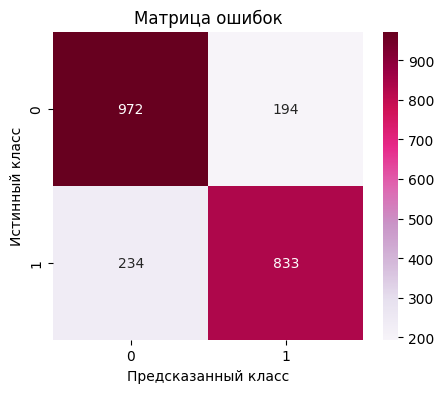

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df_clf_full = pd.read_csv("bank.csv.xls.final")

df_clf_full = pd.get_dummies(df_clf_full, drop_first=True)

X_clf = df_clf_full.drop('deposit_yes', axis=1) 
y_clf = df_clf_full['deposit_yes']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clf)
X_test_scaled = scaler.transform(X_test_clf)

logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train_scaled, y_train_clf)

y_pred_clf = logreg_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test_clf, y_pred_clf)
print(f"Доля верных ответов (Accuracy): {accuracy:.4f}\n")

print("Отчет о классификации:\n", classification_report(y_test_clf, y_pred_clf))

cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd')
plt.title('Матрица ошибок')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()